<a href="https://colab.research.google.com/github/EsraaMahmoud09/Bookstore/blob/main/Churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
## Accuracy before EDA

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score,accuracy_score,mean_squared_error
from sklearn.linear_model import Ridge, LogisticRegression

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.set_printoptions(suppress=True)

# Read Data
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn - WA_Fn-UseC_-Telco-Customer-Churn .csv')

df.drop('customerID', axis=1, inplace=True)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)

df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})  ## Converter
df = pd.get_dummies(df, drop_first=True)  ## Encoding

X = df.drop('Churn', axis=1)
y = df['Churn']

num_features = X.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X.select_dtypes(include=["object"]).columns.tolist()

preprocess = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

# Scaling is important for KNN due to distance computations
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Training
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

# Predict acc
y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
score = r2_score(y_test, y_pred)

print(f"(Baseline Accuracy): {accuracy * 100:.2f}% , (R-Square): {score}")

(Baseline Accuracy): 80.70% , (R-Square): 0.009925340360123047


In [2]:
# You are working as a Data Analyst in a telecommunications company. Your goal is to analyze customer data to
# understand the reasons behind customer churn and present data-driven insights
# and recommendations to stakeholders.
# 1. Data Cleaning 2. Exploratory Data Analysis (EDA):
# Explore the dataset:
# o Total number of customers
# o Churn rate
# o Distribution of key variables
# • Use appropriate visualizations (bar charts, box plots, histograms)

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import seaborn as sns

In [4]:

df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn - WA_Fn-UseC_-Telco-Customer-Churn .csv')

In [5]:
import os

file_path = '/content/WA_Fn-UseC_-Telco-Customer-Churn - WA_Fn-UseC_-Telco-Customer-Churn .csv'

if os.path.exists(file_path):
    print(f"File '{os.path.basename(file_path)}' found at '{file_path}'.")
else:
    print(f"File '{os.path.basename(file_path)}' not found at '{file_path}'.")
    print("Please upload the file to your Colab environment or ensure the path is correct.")
    print("You can upload files using the folder icon on the left sidebar.")

File 'WA_Fn-UseC_-Telco-Customer-Churn - WA_Fn-UseC_-Telco-Customer-Churn .csv' found at '/content/WA_Fn-UseC_-Telco-Customer-Churn - WA_Fn-UseC_-Telco-Customer-Churn .csv'.


In [6]:
df.shape

(7043, 21)

In [7]:
df.head ()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
pd.set_option("display.max_columns", None)

In [9]:
df .head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [10]:
df.sample(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
5423,5228-EXCET,Male,0,No,No,13,Yes,No,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,80.85,1008.70,Yes
3927,4390-KYULV,Male,0,Yes,No,3,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Credit card (automatic),20.55,51.15,Yes
1669,5405-ZMYXQ,Female,0,No,No,8,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Credit card (automatic),74.60,548.90,No
5656,7312-XSBAT,Male,0,No,No,1,Yes,No,DSL,Yes,No,No,No,No,No,Month-to-month,No,Electronic check,49.75,49.75,No
3974,9592-ERDKV,Male,0,Yes,No,37,Yes,Yes,DSL,Yes,No,Yes,No,Yes,Yes,One year,No,Mailed check,79.25,2911.80,No


In [11]:
df['MultipleLines'] = df['MultipleLines'].replace('No phone service', 'No')

print(df['MultipleLines'].unique())

['No' 'Yes']


In [12]:
columns_to_fix = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
for col in columns_to_fix:
  df[col] = df[col].replace('No internet service', 'No')


In [13]:
df.sample(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
5433,7879-CGSFV,Male,0,No,No,55,Yes,No,Fiber optic,Yes,Yes,No,No,Yes,Yes,One year,Yes,Mailed check,100.90,5552.05,No
366,9069-LGEUL,Male,0,Yes,No,23,Yes,No,DSL,Yes,No,No,No,No,Yes,Month-to-month,Yes,Bank transfer (automatic),59.95,1406.00,No
3073,5762-TJXGK,Female,0,No,No,52,No,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,Yes,Bank transfer (automatic),58.75,3038.55,No
5374,8065-YKXKD,Female,0,No,No,10,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,74.75,799.65,Yes
3448,5949-EBSQK,Male,0,Yes,Yes,4,Yes,No,DSL,No,No,No,Yes,No,Yes,Month-to-month,No,Credit card (automatic),61.45,229.55,Yes


In [14]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [15]:
df.describe(include='object')

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,2,3,2,2,2,2,2,2,3,2,4,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,1,3555,3641,4933,6361,4072,3096,5024,4614,4621,4999,4336,4311,3875,4171,2365,5174


In [16]:
# drop ID and Encoding Categorical
df_encoded = df.drop('customerID', axis=1)

categorical_cols = df_encoded.select_dtypes(include='object').columns

df_encoded = pd.get_dummies(df_encoded, columns=categorical_cols, drop_first=True)

print(df_encoded.head())
print(df_encoded.info())

   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  gender_Male  \
0              0       1           29.85         29.85        False   
1              0      34           56.95       1889.50         True   
2              0       2           53.85        108.15         True   
3              0      45           42.30       1840.75         True   
4              0       2           70.70        151.65        False   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  MultipleLines_Yes  \
0         True           False             False              False   
1        False           False              True              False   
2        False           False              True              False   
3        False           False             False              False   
4        False           False              True              False   

   InternetService_Fiber optic  InternetService_No  OnlineSecurity_Yes  \
0                        False               False               False  

In [17]:
# Convert Bool to int
bool_cols = df_encoded.select_dtypes(include='bool').columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)
print(df_encoded.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7043 non-null   int64  
 1   tenure                                 7043 non-null   int64  
 2   MonthlyCharges                         7043 non-null   float64
 3   TotalCharges                           7032 non-null   float64
 4   gender_Male                            7043 non-null   int64  
 5   Partner_Yes                            7043 non-null   int64  
 6   Dependents_Yes                         7043 non-null   int64  
 7   PhoneService_Yes                       7043 non-null   int64  
 8   MultipleLines_Yes                      7043 non-null   int64  
 9   InternetService_Fiber optic            7043 non-null   int64  
 10  InternetService_No                     7043 non-null   int64  
 11  Onli

In [18]:
# See categorical data
print(df_encoded.columns)

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes',
       'MultipleLines_Yes', 'InternetService_Fiber optic',
       'InternetService_No', 'OnlineSecurity_Yes', 'OnlineBackup_Yes',
       'DeviceProtection_Yes', 'TechSupport_Yes', 'StreamingTV_Yes',
       'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year',
       'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'Churn_Yes'],
      dtype='object')


In [19]:
df_encoded.describe(include='all')

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_Yes,OnlineBackup_Yes,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
count,7043.000000,7043.000000,7043.000000,7032.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2283.300441,0.504756,0.483033,0.299588,0.903166,0.421837,0.439585,0.216669,0.286668,0.344881,0.343888,0.290217,0.384353,0.387903,0.209144,0.240664,0.592219,0.216101,0.335794,0.228880,0.265370
std,0.368612,24.559481,30.090047,2266.771362,0.500013,0.499748,0.458110,0.295752,0.493888,0.496372,0.412004,0.452237,0.475363,0.475038,0.453895,0.486477,0.487307,0.406726,0.427517,0.491457,0.411613,0.472301,0.420141,0.441561
min,0.000000,0.000000,18.250000,18.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,9.000000,35.500000,401.450000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,29.000000,70.350000,1397.475000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,55.000000,89.850000,3794.737500,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [20]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [21]:
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)   ## fill missing values with median
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [22]:
df_encoded.isnull().sum()

,0
SeniorCitizen,0
tenure,0
MonthlyCharges,0
TotalCharges,11
gender_Male,0
Partner_Yes,0
Dependents_Yes,0
PhoneService_Yes,0
MultipleLines_Yes,0
InternetService_Fiber optic,0


In [23]:
df_encoded['TotalCharges'].fillna(df_encoded['TotalCharges'].median(), inplace=True)   ## fill missing values with median
print(df_encoded.isnull().sum())

SeniorCitizen                            0
tenure                                   0
MonthlyCharges                           0
TotalCharges                             0
gender_Male                              0
Partner_Yes                              0
Dependents_Yes                           0
PhoneService_Yes                         0
MultipleLines_Yes                        0
InternetService_Fiber optic              0
InternetService_No                       0
OnlineSecurity_Yes                       0
OnlineBackup_Yes                         0
DeviceProtection_Yes                     0
TechSupport_Yes                          0
StreamingTV_Yes                          0
StreamingMovies_Yes                      0
Contract_One year                        0
Contract_Two year                        0
PaperlessBilling_Yes                     0
PaymentMethod_Credit card (automatic)    0
PaymentMethod_Electronic check           0
PaymentMethod_Mailed check               0
Churn_Yes  

In [24]:
df_encoded.duplicated().sum()

np.int64(22)

In [25]:
df_encoded = df_encoded.drop_duplicates()
print(df_encoded.duplicated().sum())

0


In [26]:
df.duplicated().sum()

np.int64(0)

In [27]:
print("Before:", df.shape)
print("After:", df_encoded.shape)

Before: (7043, 21)
After: (7021, 24)


In [28]:
df_encoded.sample(5)  ## Random 5 rows

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_Yes,OnlineBackup_Yes,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
3606,0,70,101.75,7069.30,0,1,0,1,1,1,0,0,0,1,0,1,1,1,0,1,0,1,0,0
686,0,51,24.60,1266.40,1,0,0,1,1,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0
646,0,1,45.70,45.70,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,1
2718,0,62,43.70,2618.30,1,0,0,0,0,0,0,1,1,1,1,0,0,0,1,1,0,0,0,0
735,0,32,50.60,1653.45,1,1,1,0,0,0,0,0,0,1,0,1,1,0,0,0,1,0,0,0


# **Visualisation**

In [29]:
# 3. Business Questions (Answer All): 1. What are the main factors affecting customer churn?
# Problem: The company is losing customers but does not clearly know why. Hint:
# •Compare Churn with:
# o Contract
# o Monthly Charges
# o Tenure
# o Internet Service
# 2. Does contract type impact churn rate? Yes
# 3. Do customers with higher monthly charges churn more? Yes
# 4. How does tenure affect churn probability?

In [30]:
total_number_of_customers = len(df)   ## يحسب عدد كل الصفوف في الداتا، يعني كل العملاء
churn_customers = len(df[df['Churn'] == 'Yes'])   ## يحسب عدد العملاء اللي انسحبوا.
churn_rate = (churn_customers / total_number_of_customers) * 100   ## نسبة العملاء اللي انسحبوا × 100 → يعطي Churn Rate %.
print(f"Churn Rate : {churn_rate: 2f}%")

Churn Rate :  26.536987%


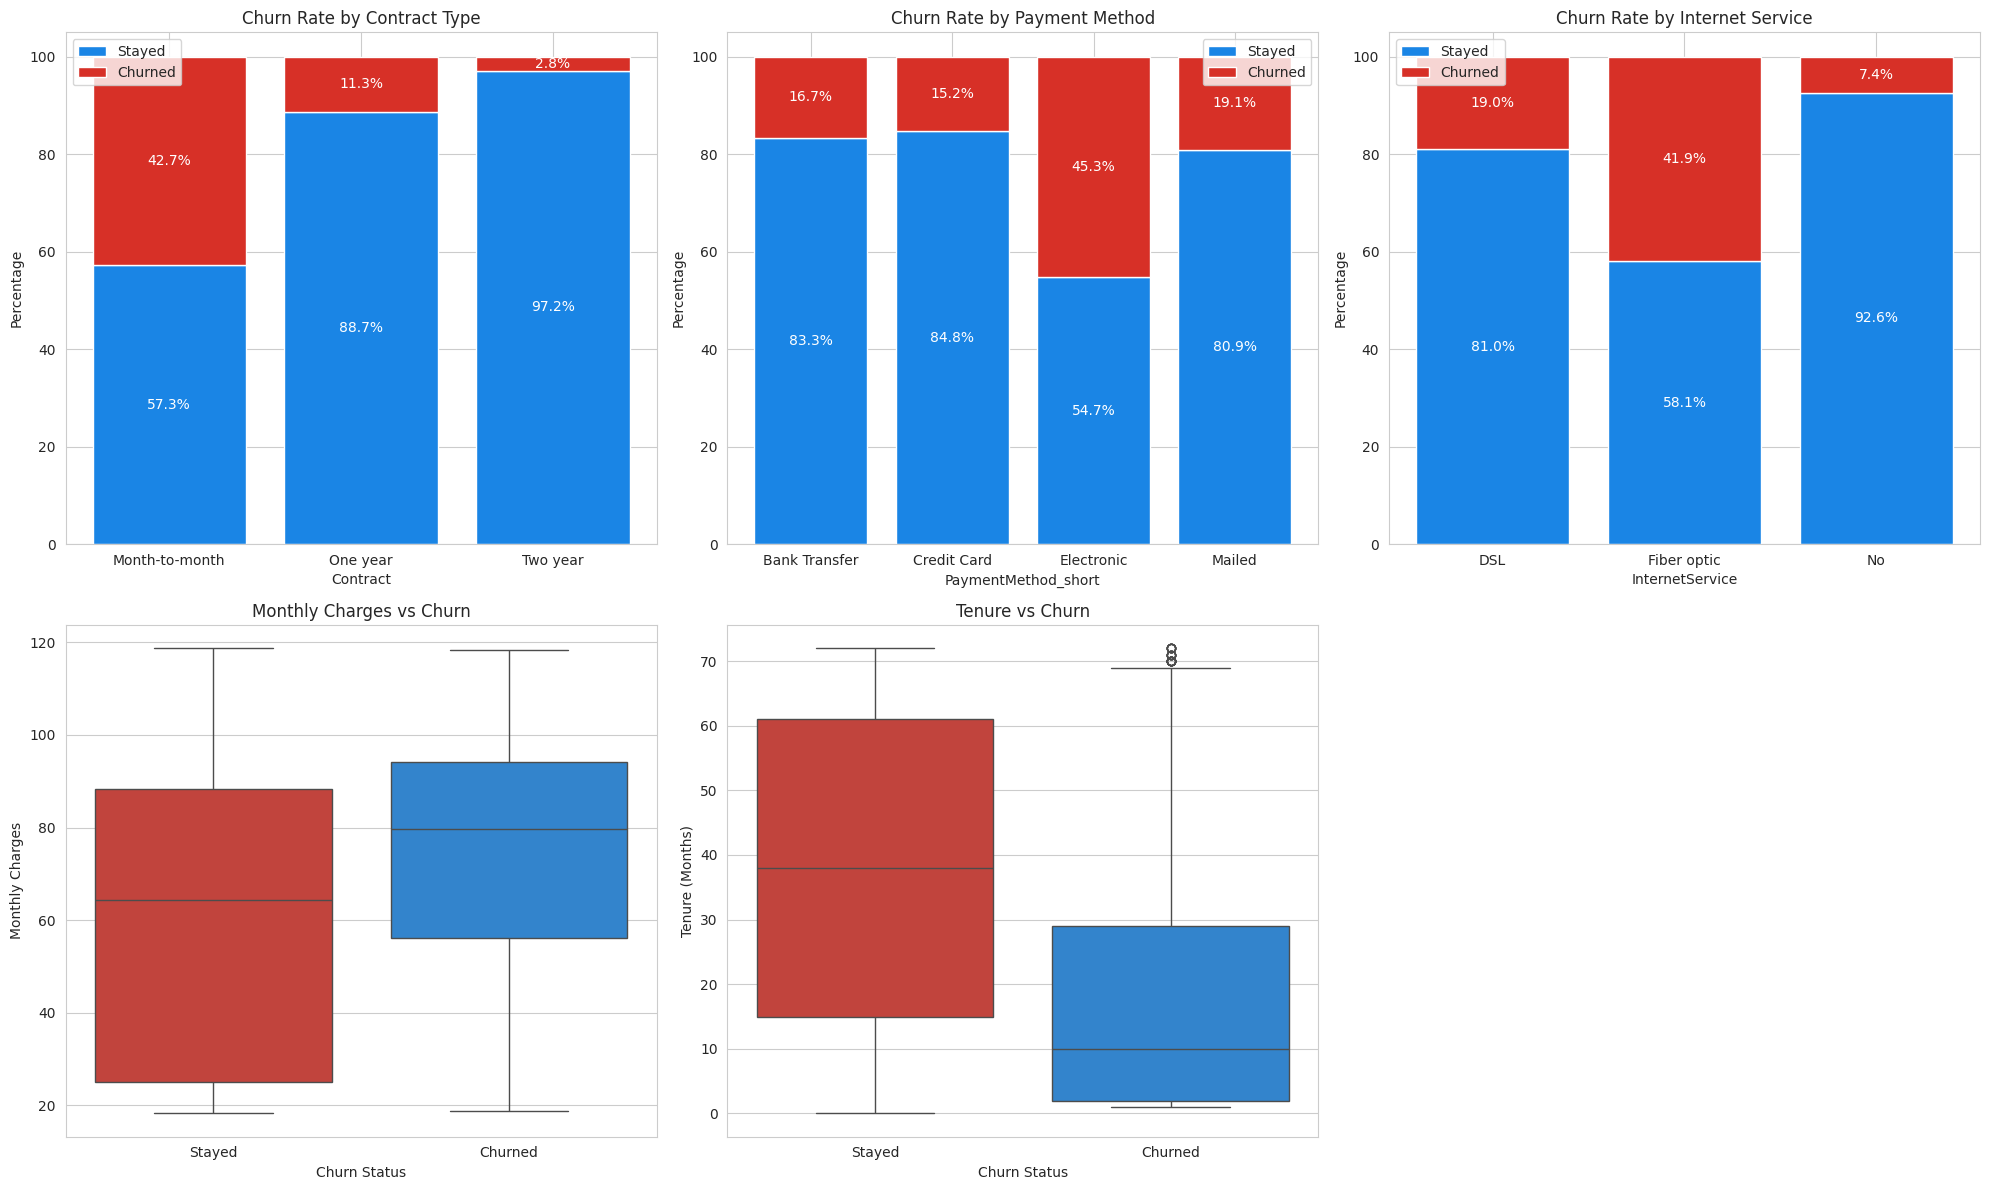

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

sns.set_style("whitegrid")

# Ensure 'Churn' column is numerical (0 for No, 1 for Yes)
# This check handles cases where Churn might already be numerical or was previously 'Yes'/'No'
if df['Churn'].dtype == 'object':
    df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

# Create Churn label from numerical Churn
df['Churn_label'] = df['Churn'].map({0:'Stayed', 1:'Churned'})
df['PaymentMethod_short'] = df['PaymentMethod'].map({
    'Electronic check':'Electronic',
    'Mailed check':'Mailed',
    'Bank transfer (automatic)':'Bank Transfer',
    'Credit card (automatic)':'Credit Card'
})

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

# =========================
# Helper function to plot stacked bar with percentages
# =========================
def plot_stacked_percentage(ax, feature, title):
    ct = pd.crosstab(df[feature], df['Churn_label'], normalize='index') * 100
    stayed = ct['Stayed']
    churned = ct['Churned']

    ax.bar(ct.index, stayed, color='#1a85e5', label='Stayed')
    ax.bar(ct.index, churned, bottom=stayed, color='#d73027', label='Churned')

    # Add percentages
    for i, (s, c) in enumerate(zip(stayed, churned)):
        ax.text(i, s/2, f'{s:.1f}%', ha='center', va='center', fontsize=10, color='white')
        ax.text(i, s + c/2, f'{c:.1f}%', ha='center', va='center', fontsize=10, color='white')

    ax.set_title(title)
    ax.set_ylabel("Percentage")
    ax.set_xlabel(feature)
    ax.legend()

# 1️⃣ Contract
plot_stacked_percentage(axes[0], 'Contract', 'Churn Rate by Contract Type')

# 2️⃣ Payment Method
plot_stacked_percentage(axes[1], 'PaymentMethod_short', 'Churn Rate by Payment Method')

# 3️⃣ Internet Service
plot_stacked_percentage(axes[2], 'InternetService', 'Churn Rate by Internet Service')

# 4️⃣ Boxplot Monthly Charges
sns.boxplot(x='Churn_label', y='MonthlyCharges', data=df, ax=axes[3], palette=['#d73027','#1a85e5'])
axes[3].set_title("Monthly Charges vs Churn")
axes[3].set_xlabel("Churn Status")
axes[3].set_ylabel("Monthly Charges")

# 5️⃣ Boxplot Tenure
sns.boxplot(x='Churn_label', y='tenure', data=df, ax=axes[4], palette=['#d73027','#1a85e5'])
axes[4].set_title("Tenure vs Churn")
axes[4].set_xlabel("Churn Status")
axes[4].set_ylabel("Tenure (Months)")

# Hide 6th empty subplot
axes[5].axis('off')

plt.tight_layout()
plt.show()

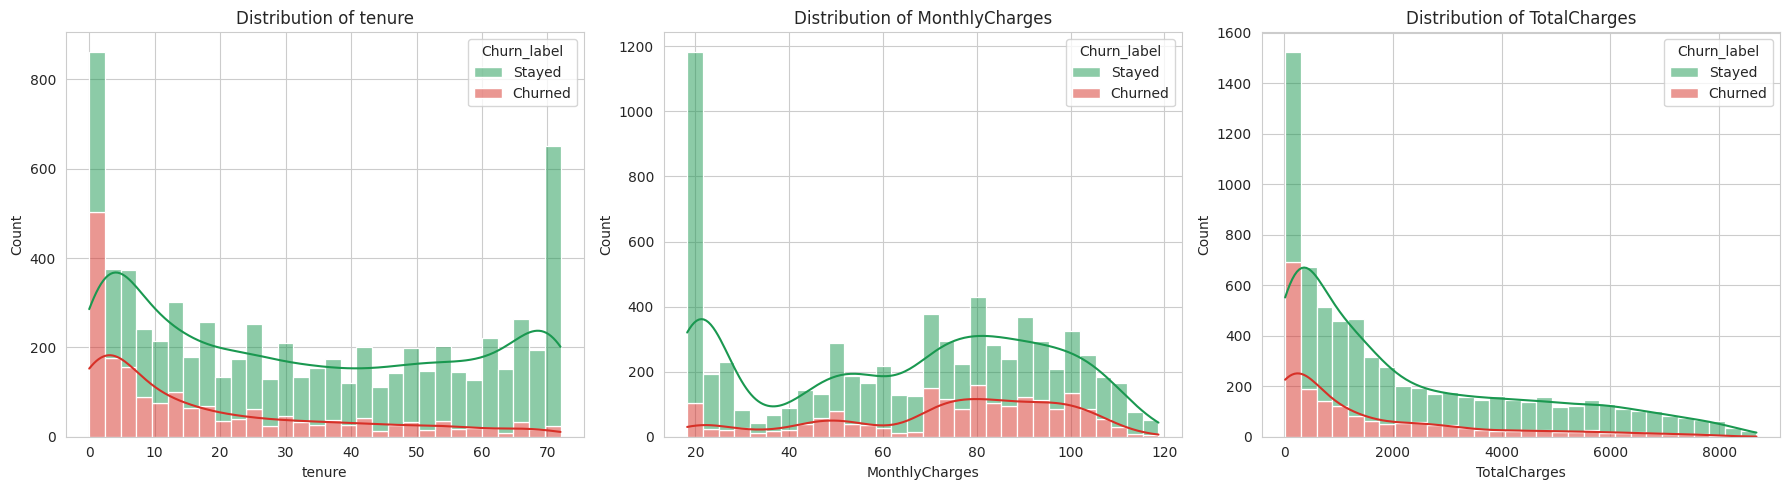

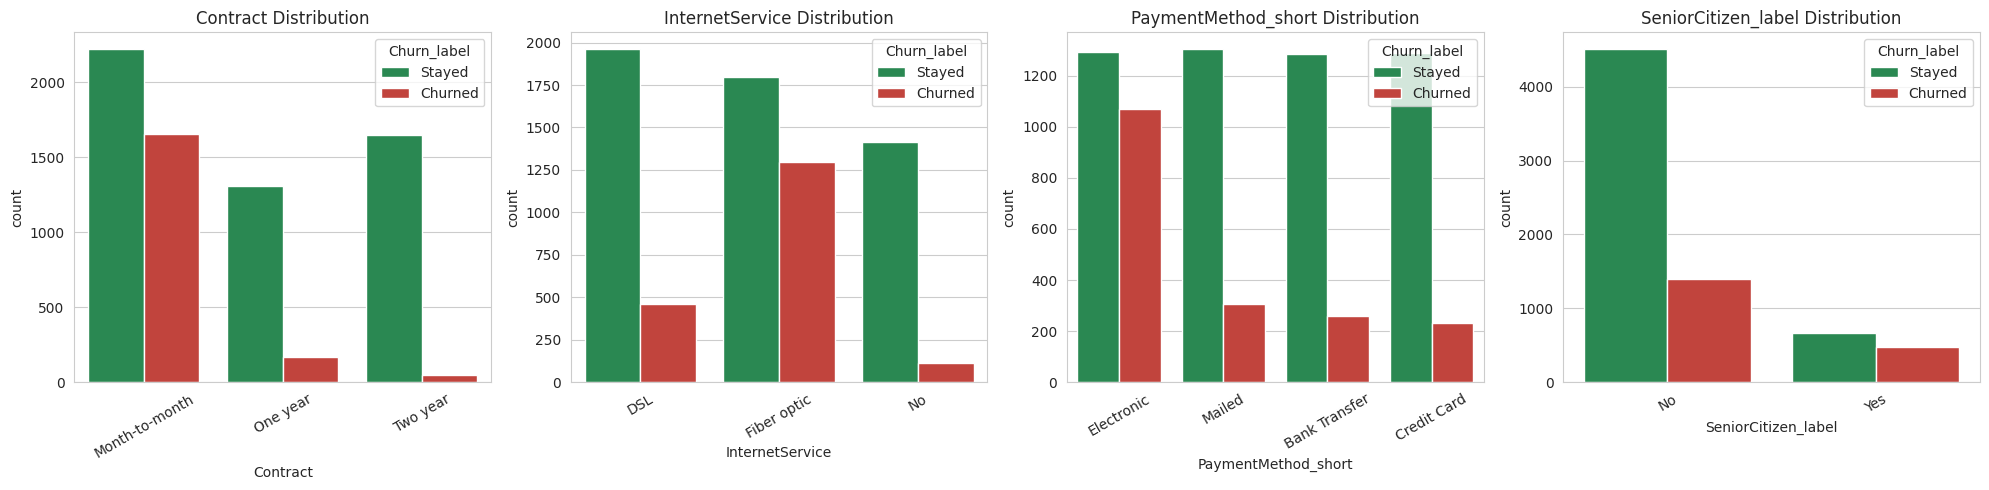

SeniorCitizen_label
No     23.606168
Yes    41.681261
Name: Churn, dtype: float64


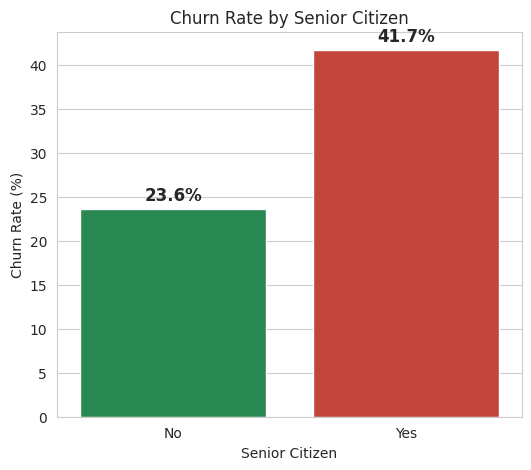

In [32]:
# =========================
# 3. Data Cleaning
# =========================

# Remove ID column
df.drop('customerID', axis=1, inplace=True, errors='ignore')

# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill missing values
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# Convert Churn to numerical ONLY IF it's still object type (contains strings 'No'/'Yes')
# This ensures robustness against repeated execution or prior conversions
if df['Churn'].dtype == 'object':
    df['Churn'] = df['Churn'].map({'No':0, 'Yes':1})

# Add label column for visualization (now based on the numerical Churn 0/1)
df['Churn_label'] = df['Churn'].map({0:'Stayed', 1:'Churned'})

# =========================
# 4. Shorten PaymentMethod names
# =========================
df['PaymentMethod_short'] = df['PaymentMethod'].map({
    'Electronic check':'Electronic',
    'Mailed check':'Mailed',
    'Bank transfer (automatic)':'Bank Transfer',
    'Credit card (automatic)':'Credit Card'
})

# =========================
# Add label column for SeniorCitizen
# =========================
df['SeniorCitizen_label'] = df['SeniorCitizen'].map({
    0: 'No',
    1: 'Yes'
})

# =========================
# 5. Numerical Distribution
# =========================
num_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(18,5))

for i, col in enumerate(num_features):
    sns.histplot(
        data=df,
        x=col,
        hue='Churn_label',
        bins=30,
        palette=['#1a9850', '#d73027'],
        alpha=0.5,
        multiple='stack',  # stacked bars
        kde=True,           # رسم الـ KDE فوق الأعمدة
        ax=axes[i]
    )
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

plt.tight_layout()
plt.show()


# =========================
# 6. Categorical Distribution
# =========================
cat_features = ['Contract', 'InternetService', 'PaymentMethod_short', 'SeniorCitizen_label']

fig, axes = plt.subplots(1, len(cat_features), figsize=(20,5)) # Changed 3 to len(cat_features) and adjusted figsize

for i, col in enumerate(cat_features):

    sns.countplot(
        data=df,
        x=col,
        hue='Churn_label',
        palette=['#1a9850', '#d73027'],
        ax=axes[i]
    )

    axes[i].set_title(f'{col} Distribution')
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


# =========================
# 7. Churn Rate by Senior Citizen
# =========================

churn_rate_senior = df.groupby('SeniorCitizen_label')['Churn'].mean() * 100

print(churn_rate_senior)

plt.figure(figsize=(6,5))

ax = sns.barplot(
    x=churn_rate_senior.index,
    y=churn_rate_senior.values,
    palette=['#1a9850', '#d73027']
)

plt.title("Churn Rate by Senior Citizen")
plt.xlabel("Senior Citizen")
plt.ylabel("Churn Rate (%)")

# =========================
# Add percentage labels on bars
# =========================
for i, value in enumerate(churn_rate_senior.values):
    ax.text(
        i,                      # x position
        value + 1,             # y position (فوق العمود)
        f"{value:.1f}%",       # النص
        ha='center',           # horizontal alignment
        fontsize=12,
        fontweight='bold'
    )

plt.show()

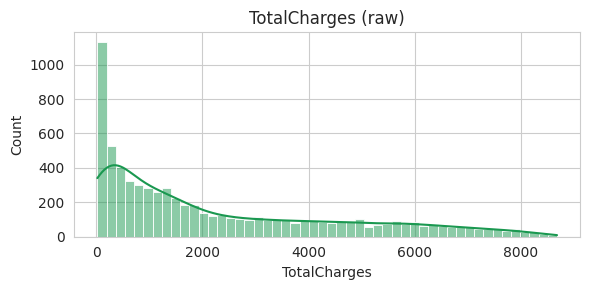

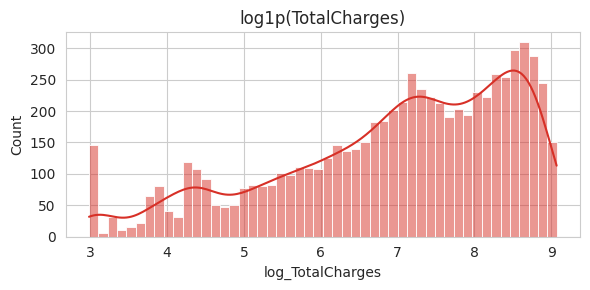

In [33]:
# =========================
# Create log column
# =========================
df_encoded['log_TotalCharges'] = np.log1p(df_encoded['TotalCharges'])

# =========================
# Plot raw TotalCharges
# =========================
plt.figure(figsize=(6,3))
sns.histplot(df_encoded['TotalCharges'], bins=50, kde=True, color='#1a9850')
plt.title("TotalCharges (raw)")
plt.tight_layout()
plt.show()

# =========================
# Plot log TotalCharges
# =========================
plt.figure(figsize=(6,3))
sns.histplot(df_encoded['log_TotalCharges'], bins=50, kde=True, color='#d73027')
plt.title("log1p(TotalCharges)")
plt.tight_layout()
plt.show()

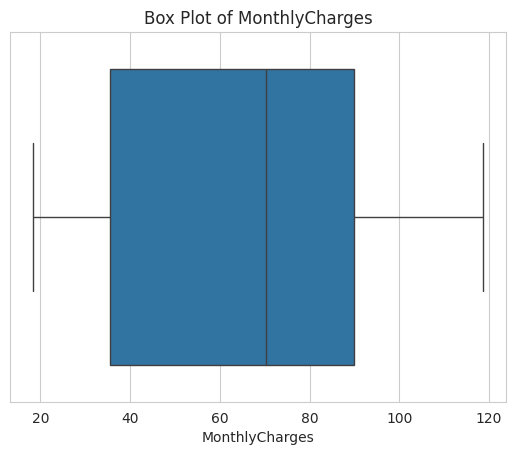

In [34]:
sns.boxplot(x=df['MonthlyCharges'])
plt.title('Box Plot of MonthlyCharges')
plt.xlabel('MonthlyCharges')
plt.show()

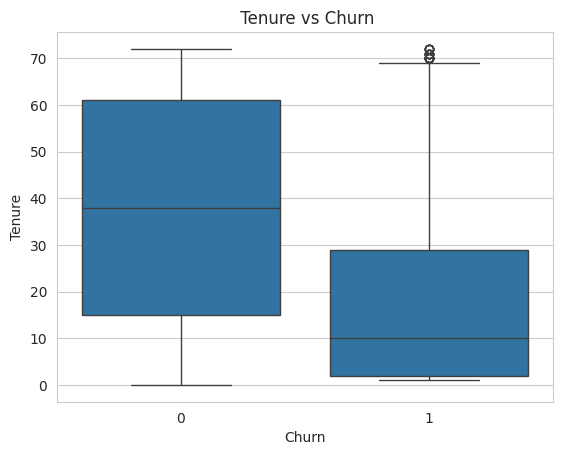

In [35]:
sns.boxplot(x="Churn", y="tenure", data=df)
plt.title(' Tenure vs Churn')
plt.xlabel('Churn')
plt.ylabel('Tenure')
plt.show()

In [36]:
# Problem: At which stage is the customer most at risk of leaving? Hint:
# Create tenure groups (0–12, 13–24, …)

  tenure_group  Churn_numeric
0         0-12      47.678161
1        13-24      28.710938
2        25-36      21.634615
3        37-48      19.028871
4        49-60      14.423077
5          61+       6.609808


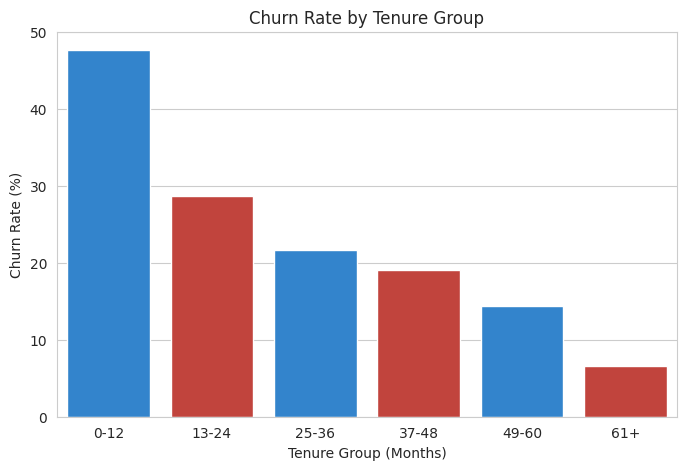

In [37]:
# إذا Churn موجود 0 و 1
df['Churn_numeric'] = df['Churn']  # لا تحتاجي تحويل إذا 0/1

# تعريف الـ bins والـ labels
bins = [0, 12, 24, 36, 48, 60, df['tenure'].max()]
labels = ['0-12', '13-24', '25-36', '37-48', '49-60', '61+']
df['tenure_group'] = pd.cut(df['tenure'], bins=bins, labels=labels, right=True)

# حساب معدل churn لكل مجموعة
tenure_churn = df.groupby('tenure_group')['Churn_numeric'].mean().reset_index()
tenure_churn['Churn_numeric'] = tenure_churn['Churn_numeric'] * 100  # تحويل لنسبة مئوية

# ترتيب حسب الـ bins الطبيعي
tenure_churn['tenure_group'] = pd.Categorical(tenure_churn['tenure_group'], categories=labels, ordered=True)
tenure_churn = tenure_churn.sort_values('tenure_group')

print(tenure_churn)

# رسم الـ bar chart
plt.figure(figsize=(8,5))
sns.barplot(x='tenure_group', y='Churn_numeric', data=tenure_churn, palette=['#1a85e5','#d73027'])
plt.title('Churn Rate by Tenure Group')
plt.xlabel('Tenure Group (Months)')
plt.ylabel('Churn Rate (%)')
plt.ylim(0,50)
plt.show()

In [38]:
# 5. Which services help reduce churn?
# Problem: Identify services that help retain customers. Hint:
# OnlineSecurity
# TechSupport
# • StreamingTV
# • Compare churn rates for each service

In [39]:
services = ['OnlineSecurity', 'TechSupport', 'StreamingTV']

# Ensure 'Churn_numeric' column exists
if 'Churn_numeric' not in df.columns:
    df['Churn_numeric'] = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

for service in services:
    churn_rate = df.groupby(service)['Churn_numeric'].mean()
    print(f"\nService: {service}")
    print(churn_rate)


Service: OnlineSecurity
OnlineSecurity
No     0.313296
Yes    0.146112
Name: Churn_numeric, dtype: float64

Service: TechSupport
TechSupport
No     0.311862
Yes    0.151663
Name: Churn_numeric, dtype: float64

Service: StreamingTV
StreamingTV
No     0.243312
Yes    0.300702
Name: Churn_numeric, dtype: float64


In [40]:
services = ['OnlineSecurity', 'TechSupport', 'StreamingTV']
churn_comparison_list = []
for service_col in services:
  churn_rate = df.groupby(service_col)['Churn_numeric'].mean().reset_index()
  churn_rate.columns = ['Category', 'Churn_Rate']
  churn_rate['Service_Type'] = service_col # Add a column to store the actual service name
  churn_comparison_list.append(churn_rate)
churn_comparison = pd.concat(churn_comparison_list)
print(churn_comparison)

  Category  Churn_Rate    Service_Type
0       No    0.313296  OnlineSecurity
1      Yes    0.146112  OnlineSecurity
0       No    0.311862     TechSupport
1      Yes    0.151663     TechSupport
0       No    0.243312     StreamingTV
1      Yes    0.300702     StreamingTV


In [41]:
pd.crosstab(churn_comparison['Service_Type'], churn_comparison['Category'])

Category,No,Yes
Service_Type,,
OnlineSecurity,1,1
StreamingTV,1,1
TechSupport,1,1


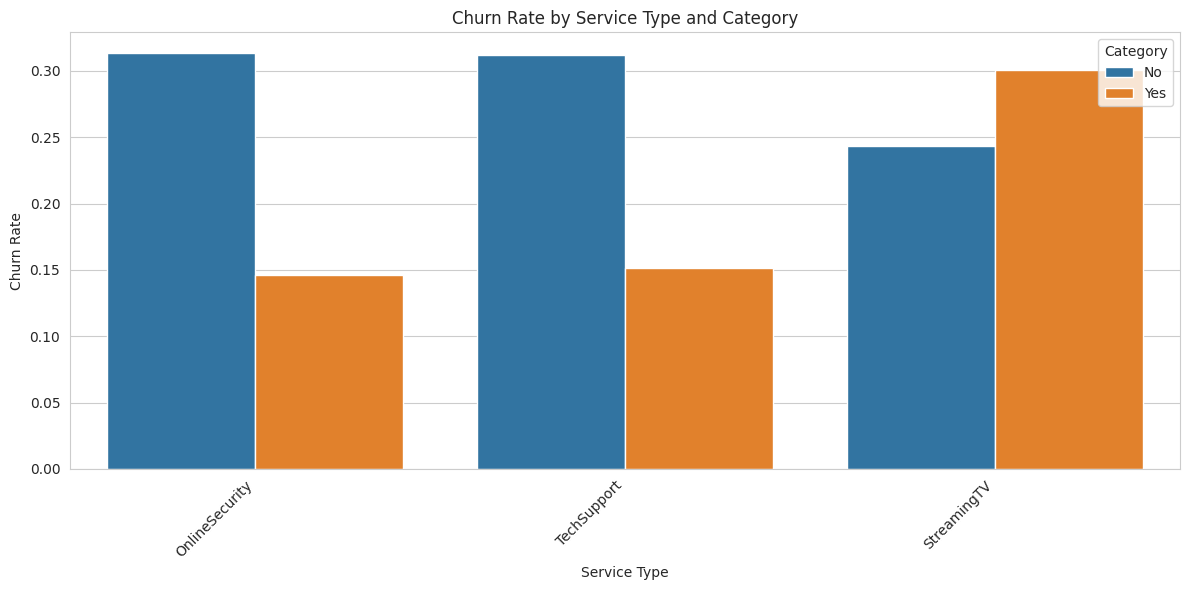

In [42]:
plt.figure(figsize=(12, 6))
ax = sns.barplot(x='Service_Type', y='Churn_Rate', hue='Category', data=churn_comparison)
plt.title('Churn Rate by Service Type and Category')
plt.xlabel('Service Type')
plt.ylabel('Churn Rate')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# New Section

In [43]:
# 4. Create Your Own Questions:
# • Generate 5 additional questions of your own that are:
# o Business-oriented
# o Answerable using the dataset
# • Answer them using visualizations and insights

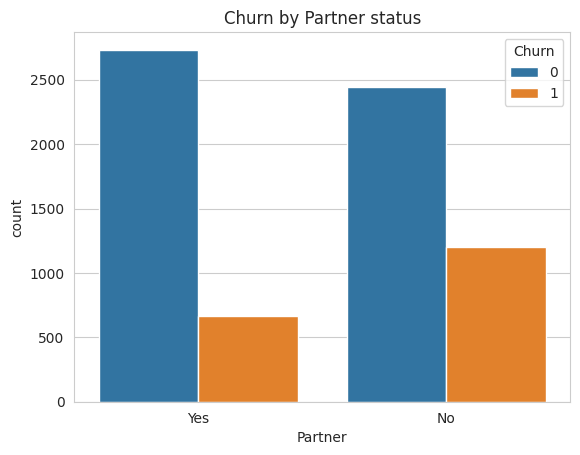

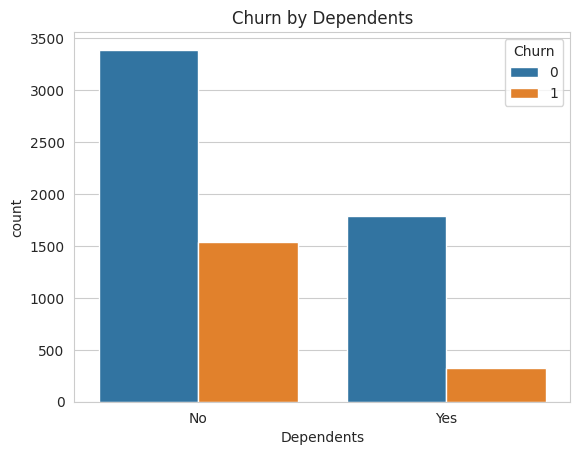

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

# Are customers with partners or dependents more loyal?
sns.countplot(x= "Partner", hue="Churn", data=df)
plt.title('Churn by Partner status')
plt.show()

sns.countplot(x= "Dependents", hue="Churn", data=df)
plt.title('Churn by Dependents')
plt.show()

  DeviceProtection  ChurnRate
0               No  41.955836
1              Yes  27.616535


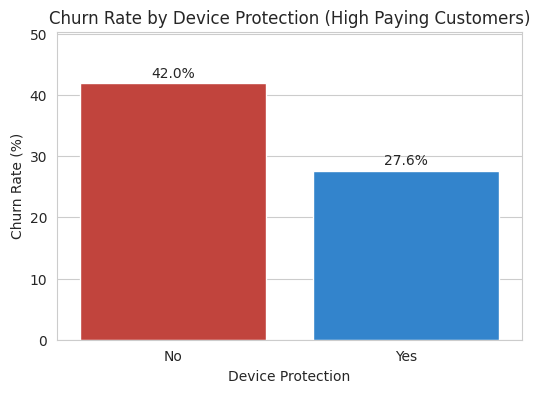

In [45]:
# Does device protection reduce churn among high -paying customers?
# ----------------------------
# 1️⃣ تحديد العملاء High Paying
# ----------------------------
high_pay_threshold = df['MonthlyCharges'].quantile(0.75)
high_paying_df = df[df['MonthlyCharges'] >= high_pay_threshold]

# ----------------------------
# 2️⃣ حساب نسبة churn حسب DeviceProtection
# ----------------------------
# df['Churn_numeric'] موجود بالفعل
device_churn = high_paying_df.groupby('DeviceProtection')['Churn_numeric'].mean() * 100
print(device_churn.reset_index(name='ChurnRate'))

# ----------------------------
# 3️⃣ رسم النتائج
# ----------------------------
plt.figure(figsize=(6,4))
sns.barplot(x=device_churn.index, y=device_churn.values, palette=['#d73027','#1a85e5'])
plt.title("Churn Rate by Device Protection (High Paying Customers)")
plt.ylabel("Churn Rate (%)")
plt.xlabel("Device Protection")

# إضافة النسب على الأعمدة
for i, val in enumerate(device_churn.values):
    plt.text(i, val + 1, f"{val:.1f}%", ha='center', fontsize=10)

plt.ylim(0, max(device_churn.values)*1.2)  # شوية مساحة فوق البارات للنص
plt.show()

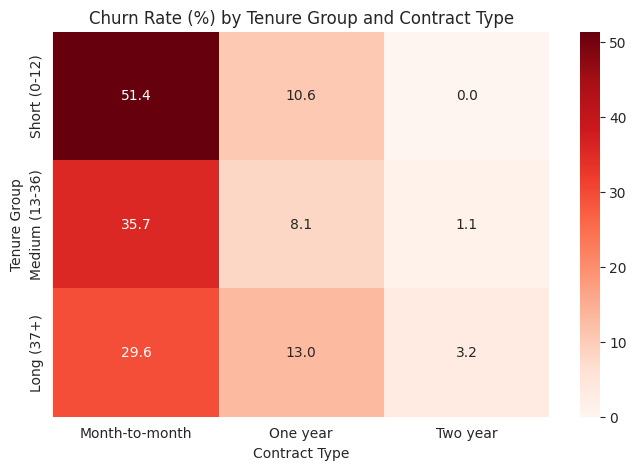

In [46]:
# Does tenure combined with contract type affect churn?
# اللون الفاتح ده نسبه الناس تمشى قليه
df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 36, 72],
    labels=["Short (0-12)", "Medium (13-36)", "Long (37+)"]
)

churn_matrix = (
    df.groupby(["TenureGroup", "Contract"])["Churn"]
    .mean() * 100  # لا داعي لـ lambda x=="Yes"
).reset_index()

# churn_matrix # This line was just printing the DataFrame, not necessary if plotting
heatmap_data = churn_matrix.pivot(
    index="TenureGroup",
    columns="Contract",
    values="Churn"
)

plt.figure(figsize=(8, 5))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap="Reds"
)

plt.title("Churn Rate (%) by Tenure Group and Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Tenure Group")
plt.show()

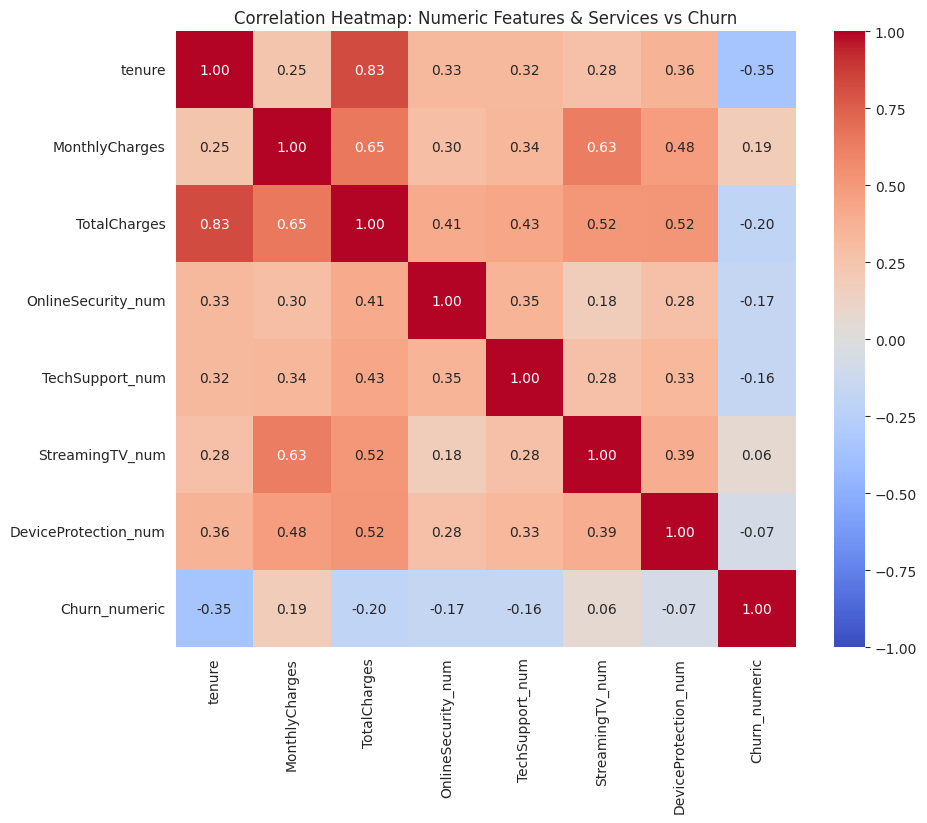

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# لو مش موجود، حول Churn لرقمي
df['Churn_numeric'] = df['Churn'].apply(lambda x: 1 if x == 1 else 0)  # لو Churn 0/1 بالفعل

# اختر المتغيرات العددية والخدمات اللي عايزين نقارنها مع Churn
features = [
    'tenure', 'MonthlyCharges', 'TotalCharges',
    'OnlineSecurity', 'TechSupport', 'StreamingTV', 'DeviceProtection'
]

# لو الخدمات عبارة عن Yes/No/No internet service، حولهم لأرقام 1/0
for col in ['OnlineSecurity','TechSupport','StreamingTV','DeviceProtection']:
    df[col+'_num'] = df[col].map({'Yes':1, 'No':0, 'No internet service':0})

# هنجمع كل المتغيرات الرقمية والخدمات الرقمية مع Churn_numeric
corr_features = ['tenure', 'MonthlyCharges', 'TotalCharges',
                 'OnlineSecurity_num', 'TechSupport_num', 'StreamingTV_num', 'DeviceProtection_num',
                 'Churn_numeric']

corr_matrix = df[corr_features].corr()

plt.figure(figsize=(10,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1
)
plt.title("Correlation Heatmap: Numeric Features & Services vs Churn")
plt.show()

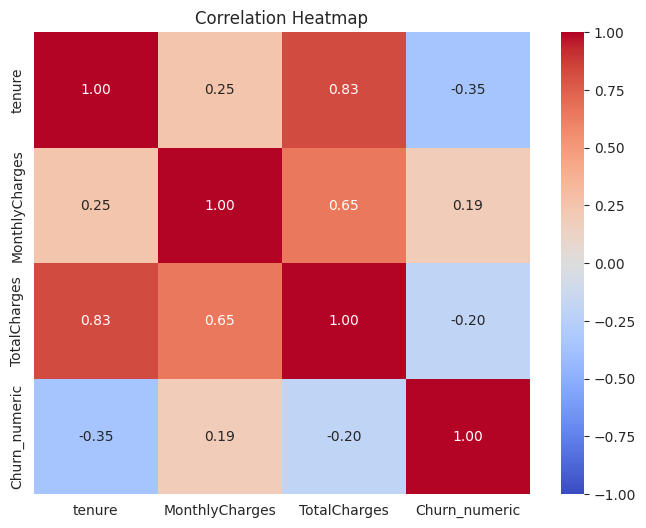

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# لو مش موجود، حول Churn لرقمي
df['Churn_numeric'] = df['Churn'].apply(lambda x: 1 if x == 1 else 0)  # لو Churn 0/1 بالفعل

# اختر المتغيرات العددية اللي عايزين نحللها
num_features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_numeric']

# احسب correlation matrix
corr_matrix = df[num_features].corr()

plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,          # اعرض القيم على كل خلية
    fmt=".2f",           # دقتين عشريتين
    cmap="coolwarm",     # تدرج لوني
    vmin=-1, vmax=1
)
plt.title("Correlation Heatmap")
plt.show()

In [49]:
# Do customers with multiple add-on services stay longer and churn less than others?
services_cols = [
    "PhoneService",
    "InternetService",
    "StreamingMovies",
    "DeviceProtection"
]

df_services = df.copy()

df_services["PhoneService"] = df_services["PhoneService"].map({"Yes": 1, "No": 0})
df_services["StreamingMovies"] = df_services["StreamingMovies"].map({"Yes": 1, "No": 0})
df_services["DeviceProtection"] = df_services["DeviceProtection"].map({"Yes": 1, "No": 0})

df_services["InternetService"] = df_services["InternetService"].apply(
    lambda x: 0 if x == "No" else 1
)

df_services["NumServices"] = df_services[services_cols].sum(axis=1)



In [50]:
summary = (
    df_services
    .groupby("NumServices")
    .agg(
        ChurnRate=("Churn", lambda x: (x == "Yes").mean() * 100),
        AvgTenure=("tenure", "mean")
    )
    .reset_index()
)

summary

,NumServices,ChurnRate,AvgTenure
0,1,0.0,28.973199
1,2,0.0,21.292100
2,3,0.0,34.419489
3,4,0.0,49.029099


In [51]:
# تحويل 'Yes'/'No' لخدمات لأرقام
services = ['OnlineSecurity', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'OnlineBackup', 'DeviceProtection']

df_services = df[services].replace({'Yes':1, 'No':0})

# حساب عدد الخدمات لكل عميل
df['NumServices'] = df_services.sum(axis=1)

# حساب churn rate لكل عدد خدمات
summary = df.groupby('NumServices')['Churn'].mean().reset_index()
summary['ChurnRate'] = summary['Churn'] * 100
print(summary)

   NumServices     Churn  ChurnRate
0            0  0.214060  21.406039
1            1  0.457557  45.755694
2            2  0.358180  35.818006
3            3  0.273703  27.370304
4            4  0.223005  22.300469
5            5  0.124343  12.434326
6            6  0.052817   5.281690


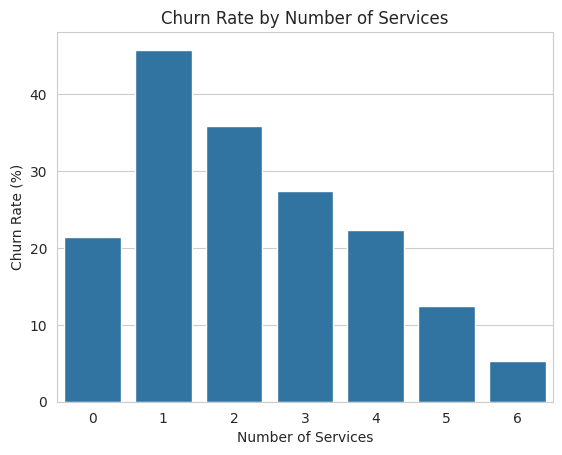

In [52]:
sns.barplot(
    data=summary,
    x="NumServices",
    y="ChurnRate"
)

plt.title("Churn Rate by Number of Services")
plt.xlabel("Number of Services")
plt.ylabel("Churn Rate (%)")
plt.show()

Text(0, 0.5, 'Average Tenure (Months)')

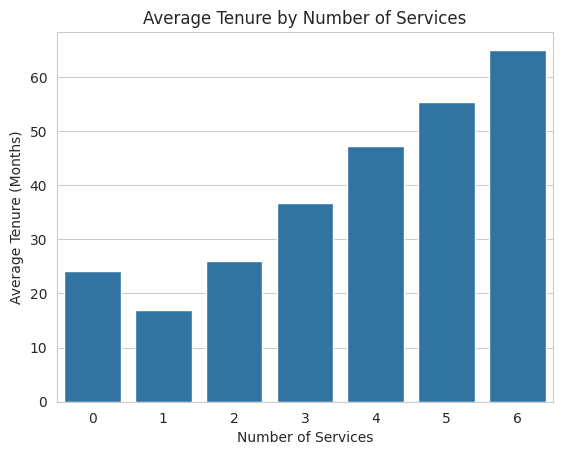

In [53]:
summary_with_tenure = (
    df
    .groupby("NumServices")
    .agg(
        ChurnRate=("Churn", "mean"),
        AvgTenure=("tenure", "mean")
    )
    .reset_index()
)
summary_with_tenure['ChurnRate'] = summary_with_tenure['ChurnRate'] * 100 # Convert ChurnRate to percentage

sns.barplot(
    data=summary_with_tenure,
    x="NumServices",
    y="AvgTenure"
)

plt.title("Average Tenure by Number of Services")
plt.xlabel("Number of Services")
plt.ylabel("Average Tenure (Months)")


In [54]:
# 5. Insights & Recommendations:
# • Extract 3–5 key insights
# • Provide clear business recommendations to reduce churn.
# • Focus on:
# o Reducing churn
# o Improving customer experience

In [55]:
"""
# key Insights (3-5 insights)

1- Customers with fewer Services are more likely to churn.
2- churn risk is highest in the early customer lifecycle.
3- High paying customers are sensitive to perceived value.
4- Long term contracts significantly reduce churn.
5- Add on services improve both retension and experience.

# Business Recommendations
( Reducing Churns & improving Customer Experience)

1- Promote Bundled Service Packages
2- Focus on Early Stage Retension programs
3- Increase value perception for High-Paying Customers
4- Incentivize Contract Upgrades
5- Use Service Count as a churn risk indicator
"""

'\n# key Insights (3-5 insights)\n\n1- Customers with fewer Services are more likely to churn.\n2- churn risk is highest in the early customer lifecycle.\n3- High paying customers are sensitive to perceived value.\n4- Long term contracts significantly reduce churn.\n5- Add on services improve both retension and experience.\n\n# Business Recommendations\n( Reducing Churns & improving Customer Experience)\n\n1- Promote Bundled Service Packages\n2- Focus on Early Stage Retension programs\n3- Increase value perception for High-Paying Customers\n4- Incentivize Contract Upgrades\n5- Use Service Count as a churn risk indicator\n'

Churn rate by number of services:
NumServices
0    0.214060
1    0.457557
2    0.358180
3    0.273703
4    0.223005
5    0.124343
6    0.052817
Name: Churn, dtype: float64

Churn rate by payment method:
PaymentMethod
Bank transfer (automatic)    0.167098
Credit card (automatic)      0.152431
Electronic check             0.452854
Mailed check                 0.191067
Name: Churn, dtype: float64
Number of High Risk Customers: 3514


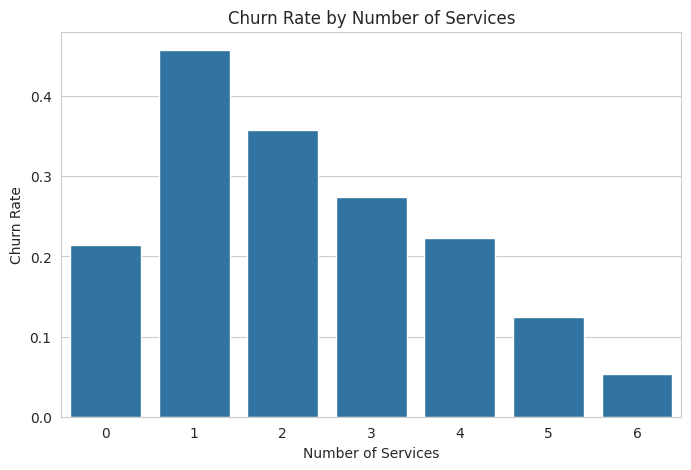

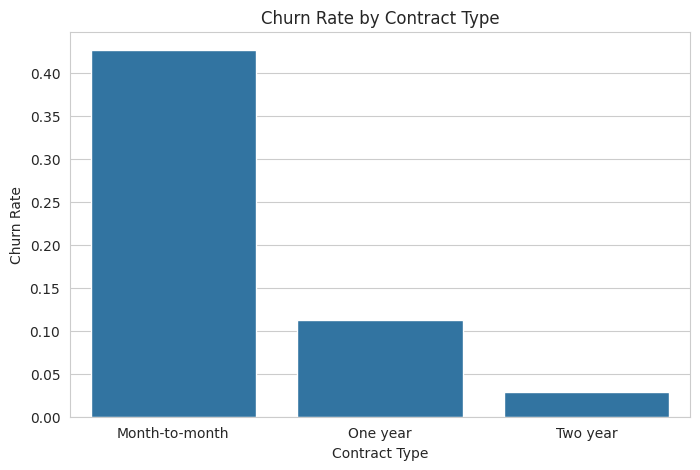

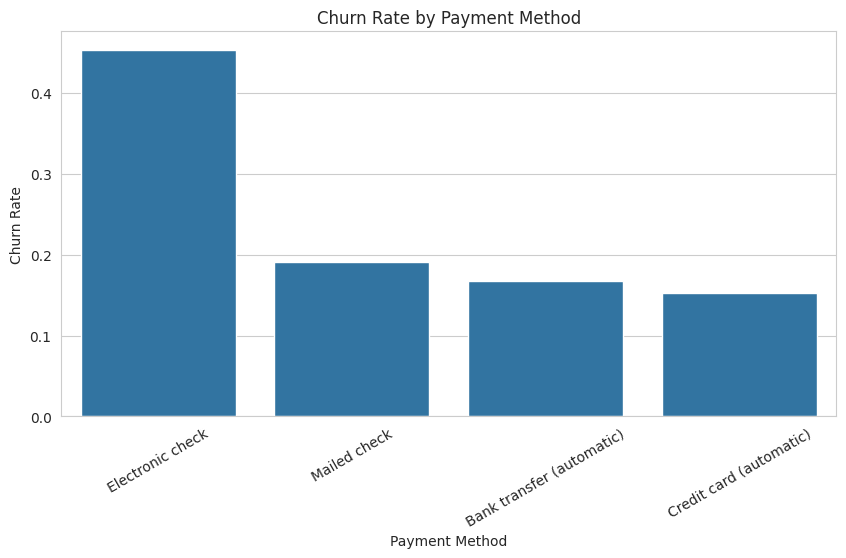

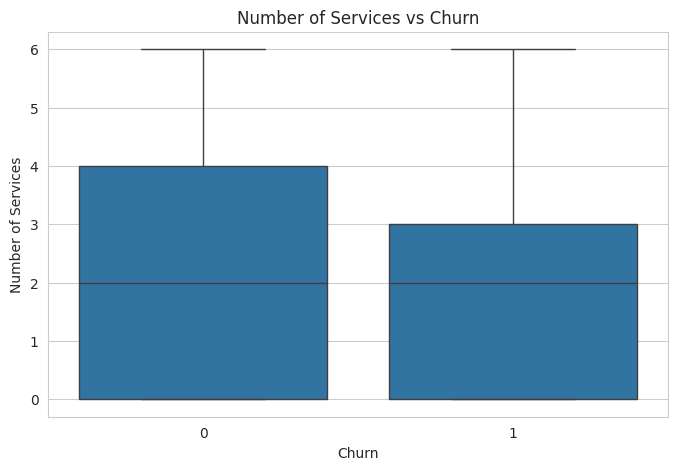

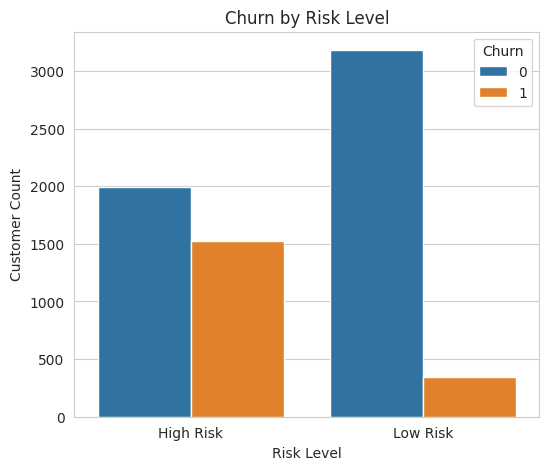

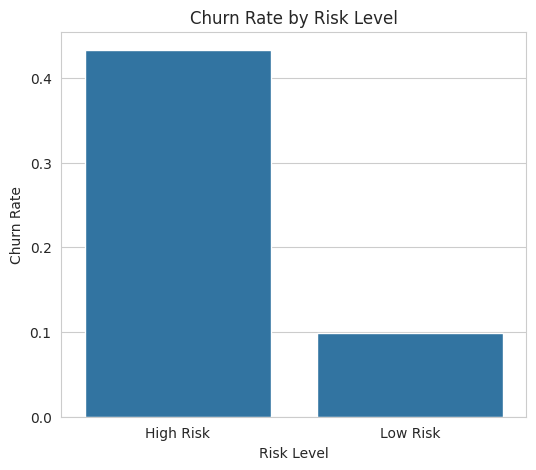

In [56]:
df['Service_Risk'] = df['NumServices'].apply(
    lambda x: 'High Risk' if x <= 2 else 'Low Risk'
)
df['Contract_Risk'] = df['Contract'].apply(
    lambda x: 'High Risk' if x == 'Month-to-month' else 'Low Risk'
)
df['Payment_Risk'] = df['PaymentMethod'].apply(
    lambda x: 'High Risk' if x == 'Electronic check' else 'Low Risk'
)
df['Risk_Score'] = (
    (df['Service_Risk'] == 'High Risk').astype(int) +
    (df['Contract_Risk'] == 'High Risk').astype(int) +
    (df['Payment_Risk'] == 'High Risk').astype(int)
)

df['Overall_Risk'] = df['Risk_Score'].apply(
    lambda x: 'High Risk' if x >= 2 else 'Low Risk'
)
# Use the numerical 'Churn' column for mean calculation
churn_by_services = df.groupby('NumServices')['Churn'].mean()

print("Churn rate by number of services:")
print(churn_by_services)
# Use the numerical 'Churn' column for mean calculation
churn_by_payment = df.groupby('PaymentMethod')['Churn'].mean()

print("\nChurn rate by payment method:")
print(churn_by_payment)
high_risk_customers = df[df['Overall_Risk'] == 'High Risk']

print("Number of High Risk Customers:", len(high_risk_customers))

high_risk_customers.head()
high_risk_customers.to_csv("high_risk_customers.csv", index=False)

df['Churn_Status'] = df['Churn_label'].map({
    1: 'Churned',
    0: 'Stayed'
})

# 1. Churn Rate by Number of Services
plt.figure(figsize=(8,5))
sns.barplot(
    x='NumServices',
    y='Churn',
    data=df,
    ci=None)
plt.title("Churn Rate by Number of Services")
plt.xlabel("Number of Services")
plt.ylabel("Churn Rate")
plt.show()

# 2. Churn Rate by Contract Type
plt.figure(figsize=(8,5))
sns.barplot(
    x='Contract',
    y='Churn',
    data=df,
    ci=None)
plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate")
plt.show()

# Churn Rate by Payment Method
plt.figure(figsize=(10,5))
sns.barplot(
    x='PaymentMethod',
    y='Churn',
    data=df,
    ci=None)
plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate")
plt.xticks(rotation=30)
plt.show()

# 4. Distribution of NumServices by Churn
plt.figure(figsize=(8,5))
sns.boxplot(
    x='Churn',
    y='NumServices',
    data=df)
plt.title("Number of Services vs Churn")
plt.xlabel("Churn")
plt.ylabel("Number of Services")
plt.show()

# 5. High Risk vs Low Risk Customers
plt.figure(figsize=(6,5))
sns.countplot(
    x='Overall_Risk',
    hue='Churn',
    data=df)
plt.title("Churn by Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Customer Count")
plt.show()

# 6. نسبة churn لكل Risk Level (أفضل visualization)
risk_churn = df.groupby('Overall_Risk')['Churn'].mean().reset_index()
plt.figure(figsize=(6,5))
sns.barplot(
    x='Overall_Risk',
    y='Churn',
    data=risk_churn)
plt.title("Churn Rate by Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Churn Rate")
plt.show()